<a href="https://colab.research.google.com/github/jnahMoch/revisedBookRecommender/blob/main/Assigning_genre_to_books.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC
from sklearn.metrics import classification_report, confusion_matrix

booksDF = pd.read_csv('cleaned_books_dataset_binary_category.csv')
booksDF['cleaned_description'] = booksDF['cleaned_description'].fillna('')

booksDF.tail(5)

,isbn13,isbn10,title,authors,categories,description,thumbnail,average_rating,num_pages,cleaned_description,simple_categories_binary
1037,9780300098259,0300098251,The Voices of Morebath,Eamon Duffy,History,- Winner of the Hawthornden Prize for Literature.,http://books.google.com/books/content?id=E45TQ...,3.70,232.0,winner hawthornden prize literature,nonfiction
1038,9780300101058,0300101058,Hamlet,William Shakespeare;Burton Raffel;Harold Bloom,Drama,"""In his introduction, Raffel offers important ...",http://books.google.com/books/content?id=MPGOo...,4.01,249.0,introduction raffel offer important background...,fiction
1039,9780300108484,0300108486,Cosmos,Witold Gombrowicz;Danuta Borchardt,Fiction,"Within the genre of crime fiction, Gombrowicz ...",http://books.google.com/books/content?id=60sZm...,4.03,208.0,within genre crime fiction gombrowicz explores...,fiction
1040,9780300111149,0300111142,Cuba,Richard Gott,History,A thorough examination of the history of the c...,http://books.google.com/books/content?id=aVq0q...,4.06,384.0,thorough examination history controversial isl...,nonfiction
1041,9780300119947,0300119941,The Annotated Waste Land with Eliot's Contempo...,Thomas Stearns Eliot;Lawrence S. Rainey,Lit,NaN,NaN,NaN,NaN,,NaN


In [2]:
booksDF.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1042 entries, 0 to 1041
Data columns (total 11 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   isbn13                    1042 non-null   int64  
 1   isbn10                    1042 non-null   object 
 2   title                     1042 non-null   object 
 3   authors                   1042 non-null   object 
 4   categories                1042 non-null   object 
 5   description               1041 non-null   object 
 6   thumbnail                 1041 non-null   object 
 7   average_rating            1041 non-null   float64
 8   num_pages                 1041 non-null   float64
 9   cleaned_description       1042 non-null   object 
 10  simple_categories_binary  1041 non-null   object 
dtypes: float64(2), int64(1), object(8)
memory usage: 89.7+ KB


In [3]:
genre_mapping = {
    'Fiction': 'Literature & Drama', 'Juvenile Fiction': 'Childrens Books',
    'Comics & Graphic Novels': 'Literature & Drama', 'Drama': 'Literature & Drama',
    'Poetry': 'Literature & Drama', 'Biography & Autobiography': 'Biography & History',
    'History': 'Biography & History', 'Literary Criticism': 'Academic & Humanities',
    'Philosophy': 'Academic & Humanities', 'Religion': 'Philosophy & Religion',
    'Juvenile Nonfiction': 'Childrens Books'
}
booksDF['genre'] = booksDF['categories'].map(genre_mapping)

In [4]:
train_df = booksDF.dropna(subset=['genre']).copy()

X = train_df['cleaned_description']
y = train_df['genre']

In [5]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [6]:
vectorizer = TfidfVectorizer(max_features=10000, ngram_range=(1, 2), sublinear_tf=True)
X_train_vec = vectorizer.fit_transform(X_train)
X_test_vec = vectorizer.transform(X_test)

In [7]:
model = LinearSVC(class_weight='balanced', C=0.5, random_state=42)
model.fit(X_train_vec, y_train)

LinearSVC(C=0.5, class_weight='balanced', random_state=42)

In [8]:
y_pred = model.predict(X_test_vec)
print("GENRE METRICS REPORT:")
print(classification_report(y_test, y_pred))

GENRE METRICS REPORT:
                       precision    recall  f1-score   support

Academic & Humanities       0.71      0.59      0.65        17
  Biography & History       0.55      0.36      0.44        33
      Childrens Books       0.73      0.35      0.48        31
   Literature & Drama       0.72      0.91      0.80       123
Philosophy & Religion       1.00      0.40      0.57         5

             accuracy                           0.70       209
            macro avg       0.74      0.52      0.59       209
         weighted avg       0.70      0.70      0.68       209



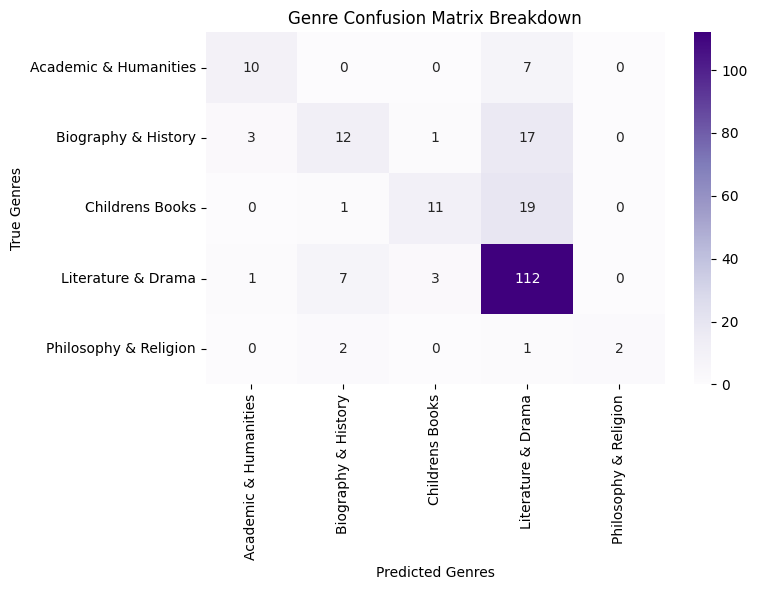

In [9]:
cm = confusion_matrix(y_test, y_pred, labels=model.classes_)
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Purples',
            xticklabels=model.classes_, yticklabels=model.classes_, ax=ax)
ax.set_title('Genre Confusion Matrix Breakdown')
ax.set_xlabel('Predicted Genres')
ax.set_ylabel('True Genres')
plt.tight_layout()
plt.show()

In [10]:
booksDF.head(5)

,isbn13,isbn10,title,authors,categories,description,thumbnail,average_rating,num_pages,cleaned_description,simple_categories_binary,genre
0,9780002005883,0002005883,Gilead,Marilynne Robinson,Fiction,A NOVEL THAT READERS and critics have been eag...,http://books.google.com/books/content?id=KQZCP...,3.85,247.0,novel reader critic eagerly anticipating decad...,fiction,Literature & Drama
1,9780002261982,0002261987,Spider's Web,Charles Osborne;Agatha Christie,Fiction,A new 'Christie for Christmas' -- a full-lengt...,http://books.google.com/books/content?id=gA5GP...,3.83,241.0,new christie christmas fulllength novel adapte...,fiction,Literature & Drama
2,9780006163831,0006163831,The One Tree,Stephen R. Donaldson,Fiction,Volume Two of Stephen Donaldson's acclaimed se...,http://books.google.com/books/content?id=OmQaw...,3.97,479.0,volume two stephen donaldsons acclaimed second...,fiction,Literature & Drama
3,9780006178736,0006178731,Rage of angels,Sidney Sheldon,Fiction,"A memorable, mesmerizing heroine Jennifer -- b...",http://books.google.com/books/content?id=FKo2T...,3.93,512.0,memorable mesmerizing heroine jennifer brillia...,fiction,Literature & Drama
4,9780006280897,0006280897,The Four Loves,Clive Staples Lewis,Religion,Lewis' work on the nature of love divides love...,http://books.google.com/books/content?id=XhQ5X...,4.15,170.0,lewis work nature love divide love four catego...,nonfiction,Philosophy & Religion


In [11]:
booksDF["genre"].unique()

array(['Literature & Drama', 'Philosophy & Religion',
       'Biography & History', 'Childrens Books', 'Academic & Humanities',
       nan], dtype=object)

In [12]:
booksDF.to_csv('books_with_categories_and_genre.csv', index=False)

In [13]:
Books_with_genreDF = pd.read_csv("books_with_categories_and_genre.csv")
Books_with_genreDF.head()

,isbn13,isbn10,title,authors,categories,description,thumbnail,average_rating,num_pages,cleaned_description,simple_categories_binary,genre
0,9780002005883,0002005883,Gilead,Marilynne Robinson,Fiction,A NOVEL THAT READERS and critics have been eag...,http://books.google.com/books/content?id=KQZCP...,3.85,247.0,novel reader critic eagerly anticipating decad...,fiction,Literature & Drama
1,9780002261982,0002261987,Spider's Web,Charles Osborne;Agatha Christie,Fiction,A new 'Christie for Christmas' -- a full-lengt...,http://books.google.com/books/content?id=gA5GP...,3.83,241.0,new christie christmas fulllength novel adapte...,fiction,Literature & Drama
2,9780006163831,0006163831,The One Tree,Stephen R. Donaldson,Fiction,Volume Two of Stephen Donaldson's acclaimed se...,http://books.google.com/books/content?id=OmQaw...,3.97,479.0,volume two stephen donaldsons acclaimed second...,fiction,Literature & Drama
3,9780006178736,0006178731,Rage of angels,Sidney Sheldon,Fiction,"A memorable, mesmerizing heroine Jennifer -- b...",http://books.google.com/books/content?id=FKo2T...,3.93,512.0,memorable mesmerizing heroine jennifer brillia...,fiction,Literature & Drama
4,9780006280897,0006280897,The Four Loves,Clive Staples Lewis,Religion,Lewis' work on the nature of love divides love...,http://books.google.com/books/content?id=XhQ5X...,4.15,170.0,lewis work nature love divide love four catego...,nonfiction,Philosophy & Religion


In [14]:
Books_with_genreDF.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1042 entries, 0 to 1041
Data columns (total 12 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   isbn13                    1042 non-null   int64  
 1   isbn10                    1042 non-null   object 
 2   title                     1042 non-null   object 
 3   authors                   1042 non-null   object 
 4   categories                1042 non-null   object 
 5   description               1041 non-null   object 
 6   thumbnail                 1041 non-null   object 
 7   average_rating            1041 non-null   float64
 8   num_pages                 1041 non-null   float64
 9   cleaned_description       1041 non-null   object 
 10  simple_categories_binary  1041 non-null   object 
 11  genre                     1041 non-null   object 
dtypes: float64(2), int64(1), object(9)
memory usage: 97.8+ KB


In [15]:
Books_with_genreDF["genre"].unique()

array(['Literature & Drama', 'Philosophy & Religion',
       'Biography & History', 'Childrens Books', 'Academic & Humanities',
       nan], dtype=object)